In [2]:
# ============================================================
# Cell 1 - Imports and File Upload
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


np.random.seed(42)
tf.random.set_seed(42)

uploaded = files.upload()
FILE_PATH = list(uploaded.keys())[0]

Saving Oil well.xlsx to Oil well.xlsx


Dataset shape: (2940, 2)


,date,oil_volume
0,2013-01-01,49.0
1,2013-01-02,49.0
2,2013-01-03,49.0
3,2013-01-04,49.0
4,2013-01-05,44.0


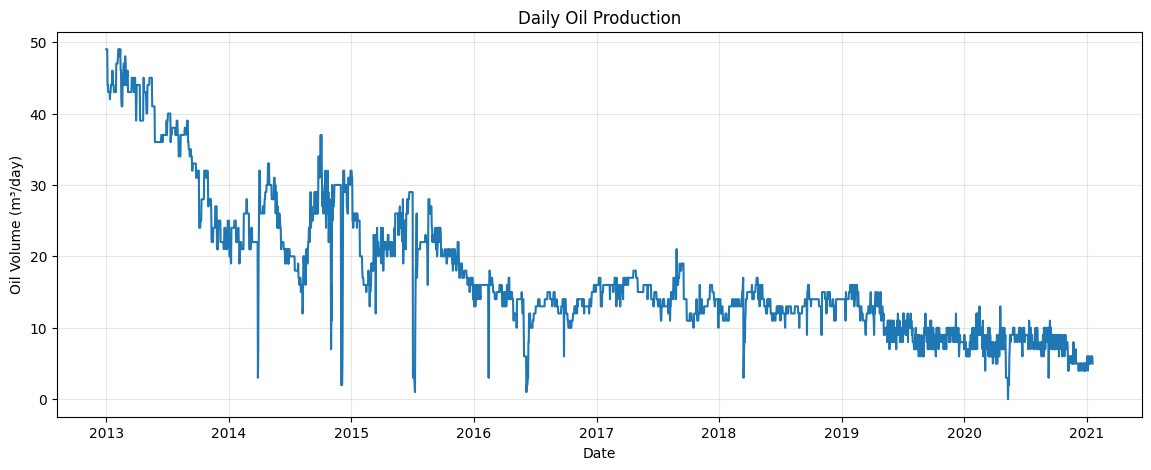

In [4]:
# ============================================================
# Cell 2 - Load and Clean Dataset
# ============================================================

df = pd.read_excel(FILE_PATH, skiprows=2)

# Remove newlines and extra spaces from column names
df.columns = (
    df.columns
    .str.replace("\n", "", regex=False)
    .str.strip()
)

# Keep only the columns required for this project
df = df[
    ["Date", "Oil volume (m3/day)"]
].rename(
    columns={
        "Date": "date",
        "Oil volume (m3/day)": "oil_volume"
    }
)

df["date"] = pd.to_datetime(df["date"])

# Arrange chronologically and handle missing dates
df = (
    df.drop_duplicates("date")
    .sort_values("date")
    .set_index("date")
    .asfreq("D")
    .ffill()
    .dropna()
    .reset_index()
)

print("Dataset shape:", df.shape)
display(df.head())

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["oil_volume"])
plt.title("Daily Oil Production")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# ============================================================
# Cell 3 - Train-Test Split and Scaling
# ============================================================

TRAIN_RATIO = 0.80

values = df[["oil_volume"]].values
split_index = int(len(values) * TRAIN_RATIO)

train_values = values[:split_index]
test_values = values[split_index:]

scaler = MinMaxScaler()

# Learn scaling rules from training data only
scaler.fit(train_values)

# Apply the same scaling rules to all values
scaled_values = scaler.transform(values)

print("Training rows:", len(train_values))
print("Testing rows:", len(test_values))

Training rows: 2352
Testing rows: 588


In [6]:
# ============================================================
# Cell 4 - Create LSTM Sequences
# ============================================================

LOOKBACK = 30


def create_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)


train_scaled = scaled_values[:split_index]

# Include the final 30 training days for test context
test_scaled = scaled_values[split_index - LOOKBACK:]


X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK
)

X_test, y_test = create_sequences(
    test_scaled,
    LOOKBACK
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (2322, 30, 1)
y_train: (2322, 1)
X_test : (588, 30, 1)
y_test : (588, 1)


In [7]:
# ============================================================
# Cell 5 - Build and Train LSTM
# ============================================================

model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mean_squared_error"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping]
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0416 - val_loss: 8.6563e-04
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0096 - val_loss: 8.4893e-04
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0080 - val_loss: 7.4381e-04
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0062 - val_loss: 7.2521e-04
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0057 - val_loss: 7.0334e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0050 - val_loss: 7.0266e-04
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050 - val_loss: 6.6940e-04
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045 - val_loss: 6.7945e-04
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0044 - val_loss: 6.7446e-04
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0045 - val_loss: 6.6362e-04
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0042 - val_loss: 6.6529e-04
Epoch 12/50
66/66 ━

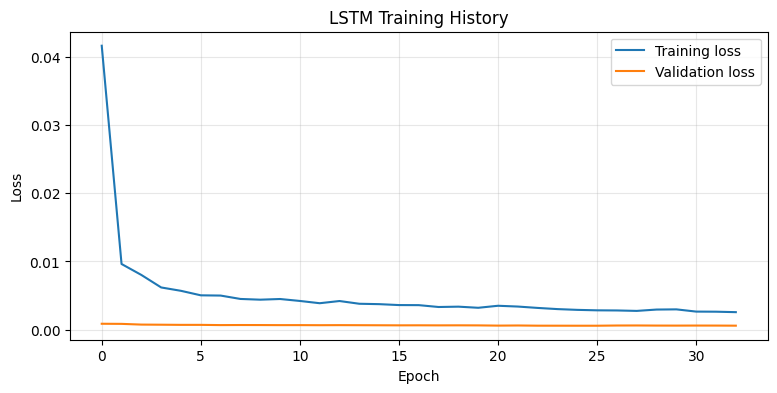

In [8]:
# ============================================================
# Cell 6 - Plot Training History
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
# ============================================================
# Cell 7 - Prediction and Evaluation
# ============================================================

scaled_predictions = model.predict(
    X_test,
    verbose=0
)

predictions = scaler.inverse_transform(
    scaled_predictions
).flatten()

actual_values = scaler.inverse_transform(
    y_test
).flatten()


mae = mean_absolute_error(
    actual_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        predictions
    )
)


print(f"MAE  : {mae:.2f} m³/day")
print(f"RMSE : {rmse:.2f} m³/day")


test_dates = (
    df["date"]
    .iloc[split_index:]
    .reset_index(drop=True)
)

results = pd.DataFrame({
    "date": test_dates,
    "actual": actual_values,
    "predicted": predictions
})

display(results.head(10))

MAE  : 1.19 m³/day
RMSE : 1.50 m³/day


,date,actual,predicted
0,2019-06-11,8.0,10.317039
1,2019-06-12,9.0,9.746021
2,2019-06-13,7.0,9.627878
3,2019-06-14,9.0,8.990364
4,2019-06-15,9.0,9.102413
5,2019-06-16,11.0,9.200984
6,2019-06-17,9.0,9.866411
7,2019-06-18,12.0,9.771202
8,2019-06-19,9.0,10.582193
9,2019-06-20,9.0,10.274170


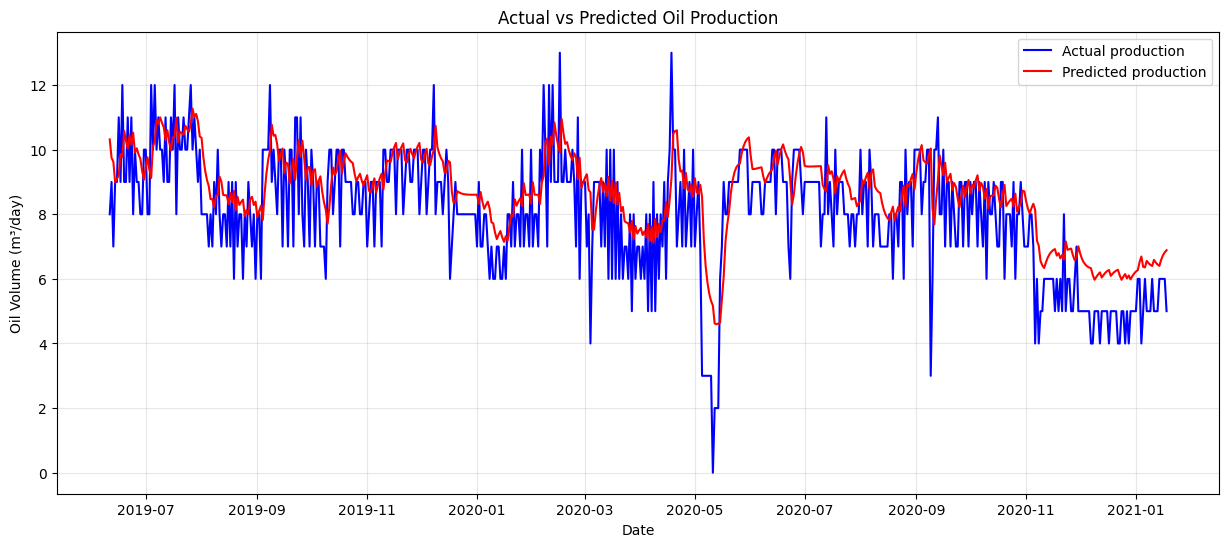

In [10]:
# ============================================================
# Cell 8 - Plot Actual vs Predicted Values
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    actual_values,
    label="Actual production",
    color="blue"
)

plt.plot(
    test_dates,
    predictions,
    label="Predicted production",
    color="red"
)

plt.title("Actual vs Predicted Oil Production")
plt.xlabel("Date")
plt.ylabel("Oil Volume (m³/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# ============================================================
# Cell 9 - Predict Next Day
# ============================================================

# Take the latest 30 days
last_sequence = scaled_values[-LOOKBACK:]

# Convert to LSTM input shape
last_sequence = last_sequence.reshape(
    1,
    LOOKBACK,
    1
)

# Make prediction
next_day_scaled = model.predict(
    last_sequence,
    verbose=0
)

# Return prediction to the original unit
next_day_prediction = scaler.inverse_transform(
    next_day_scaled
)[0, 0]

next_date = (
    df["date"].max()
    + pd.Timedelta(days=1)
)

print("Prediction date:", next_date.date())

print(
    f"Predicted oil production: "
    f"{next_day_prediction:.2f} m³/day"
)

Prediction date: 2021-01-19
Predicted oil production: 6.70 m³/day


In [12]:
# ============================================================
# Cell 10 - Save Model
# ============================================================

import joblib

model.save("oil_production_lstm1.keras")
joblib.dump(
    scaler,
    "oil_production_scaler1.pkl"
)

print("Model and scaler saved.")

Model and scaler saved.
